## 1. Setup and Path Configuration

In [8]:
import json
import cv2
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Tuple
from pycocotools import mask as mask_utils

# ================= CONFIGURAÇÃO DE CAMINHOS =================
unb_server = True

if unb_server:
    LOCAL_PATH = "/home/antoniovinicius/projects/sandbox_sam3"
    LOG_DIR = Path(f"{LOCAL_PATH}/logs/olds/isic_10k_train_seg_500")
else:
    LOCAL_PATH = "/home/avmoura_linux/Documents/unb/sandbox_sam3"
    LOG_DIR = Path(f"{LOCAL_PATH}/logs/olds/isic_10k_train_seg_500")

CONFIG = {
    "train_stats": LOG_DIR / "train_stats.json",
    "val_stats": LOG_DIR / "val_stats.json",
    "best_stats": LOG_DIR / "best_stats.json",
    
    # Configurações do seu script de visualização
    "images_dir": Path(f"{LOCAL_PATH}/datasets/isic_10k_dataset/valid/"),
    "pred_json": Path(f"{LOG_DIR}/dumps/isic_10k/coco_predictions_segm.json"),
    "gt_json": Path(f"{LOCAL_PATH}/datasets/isic_10k_dataset/valid/_annotations.coco.json"),
    "score_threshold": 0.60,
    "mask_alpha": 0.45
}

## 2. Data Loading

In [9]:
def load_jsonl(filepath: Path) -> pd.DataFrame:
    if not filepath.exists():
        print(f"File not found: {filepath}")
        return pd.DataFrame()
        
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line.strip()))
    return pd.DataFrame(data)

# Carregando as métricas
df_train = load_jsonl(CONFIG["train_stats"])
df_val = load_jsonl(CONFIG["val_stats"])
df_best = load_jsonl(CONFIG["best_stats"])

print(f"Training lines loaded: {len(df_train)}")
print(f"Validation lines loaded: {len(df_val)}")

Training lines loaded: 10
Validation lines loaded: 2


## 3. Training Loss Analysis

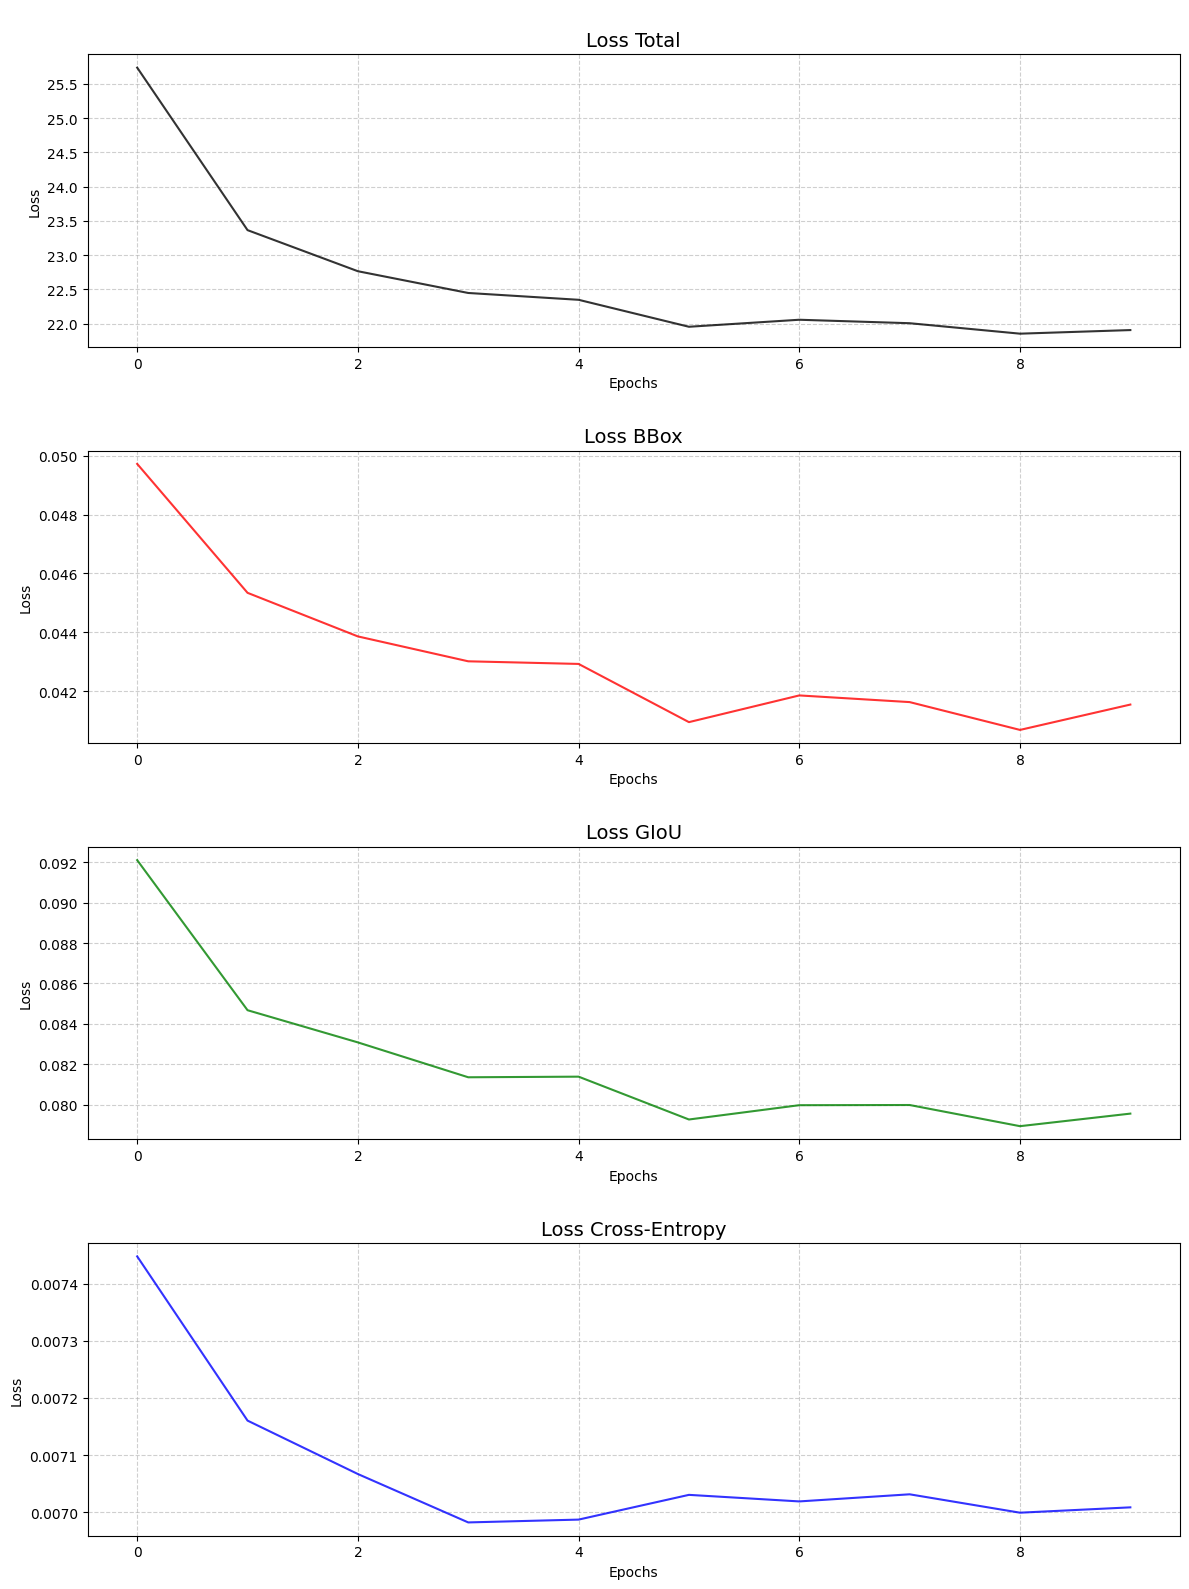

In [10]:
# Definindo as métricas principais de treino que queremos observar
train_metrics = {
    "\nLoss Total": ("Losses/train_all_loss", "black"),
    "\nLoss BBox": ("Losses/train_all_loss_bbox", "red"),
    "\nLoss GIoU": ("Losses/train_all_loss_giou", "green"),
    "\nLoss Cross-Entropy": ("Losses/train_all_loss_ce", "blue")
}

fig, axes = plt.subplots(len(train_metrics), 1, figsize=(12, 4 * len(train_metrics)))

for i, (title, (col_name, color)) in enumerate(train_metrics.items()):
    if col_name in df_train.columns:
        axes[i].plot(df_train.index, df_train[col_name], color=color, alpha=0.8)
        axes[i].set_title(title, fontsize=14)
        axes[i].set_xlabel("Epochs")
        axes[i].set_ylabel("Loss")
        axes[i].grid(True, linestyle="--", alpha=0.6)
    else:
        axes[i].text(0.5, 0.5, f"Metric {col_name} not found", ha="center", va="center")

plt.tight_layout()
plt.show()

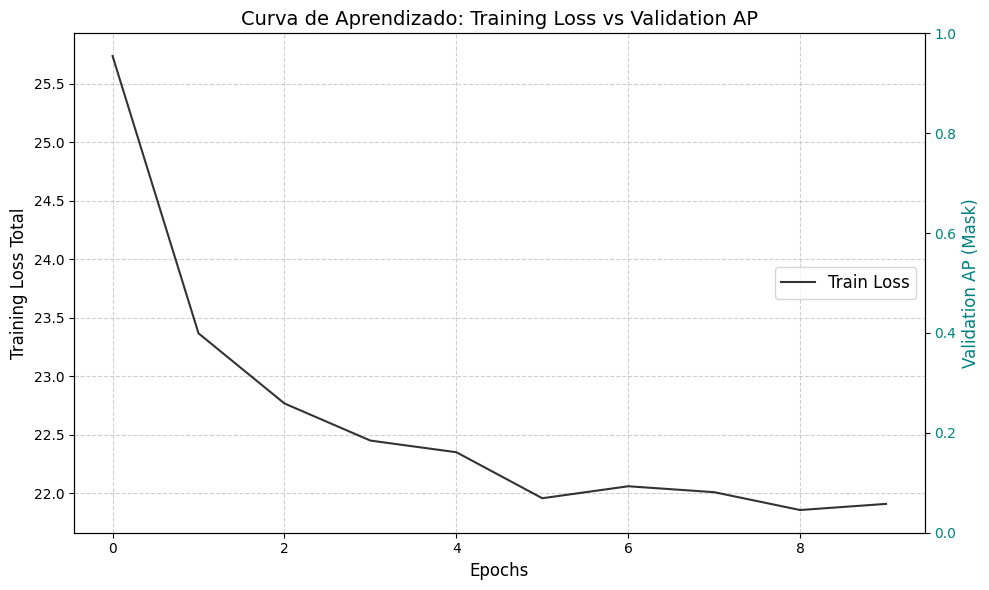

In [11]:
## 3. Loss de Treino vs AP de Validação
epochs_train = df_train['Trainer/epoch'] if 'Trainer/epoch' in df_train.columns else df_train.index
epochs_val = df_val['Trainer/epoch'] if 'Trainer/epoch' in df_val.columns else df_val.index

fig, ax1 = plt.subplots(figsize=(10, 6))

# Eixo Y Esquerdo: Loss de Treino
color1 = 'black'
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Training Loss Total', color=color1, fontsize=12)
if "Losses/train_all_loss" in df_train.columns:
    ax1.plot(epochs_train, df_train["Losses/train_all_loss"], color=color1, label="Train Loss", alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle="--", alpha=0.6)

# Eixo Y Direito: AP de Validação (Mask ou BBox)
ax2 = ax1.twinx()  # Instancia um segundo eixo Y que compartilha o mesmo eixo X
color2 = 'teal'
ax2.set_ylabel('Validation AP (Mask)', color=color2, fontsize=12)
# Vamos usar a AP de segmentação como métrica principal de sucesso
val_metric = 'Meters_train/val_isic_eval/detection/coco_eval_segm_AP'
if val_metric in df_val.columns:
    ax2.plot(epochs_val, df_val[val_metric], color=color2, marker='o', label="Val Mask AP", linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

# Adicionando as legendas de ambos os eixos juntas
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right', fontsize=12)

plt.title("Curva de Aprendizado: Training Loss vs Validation AP", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Validation Metrics (COCO Evaluation)

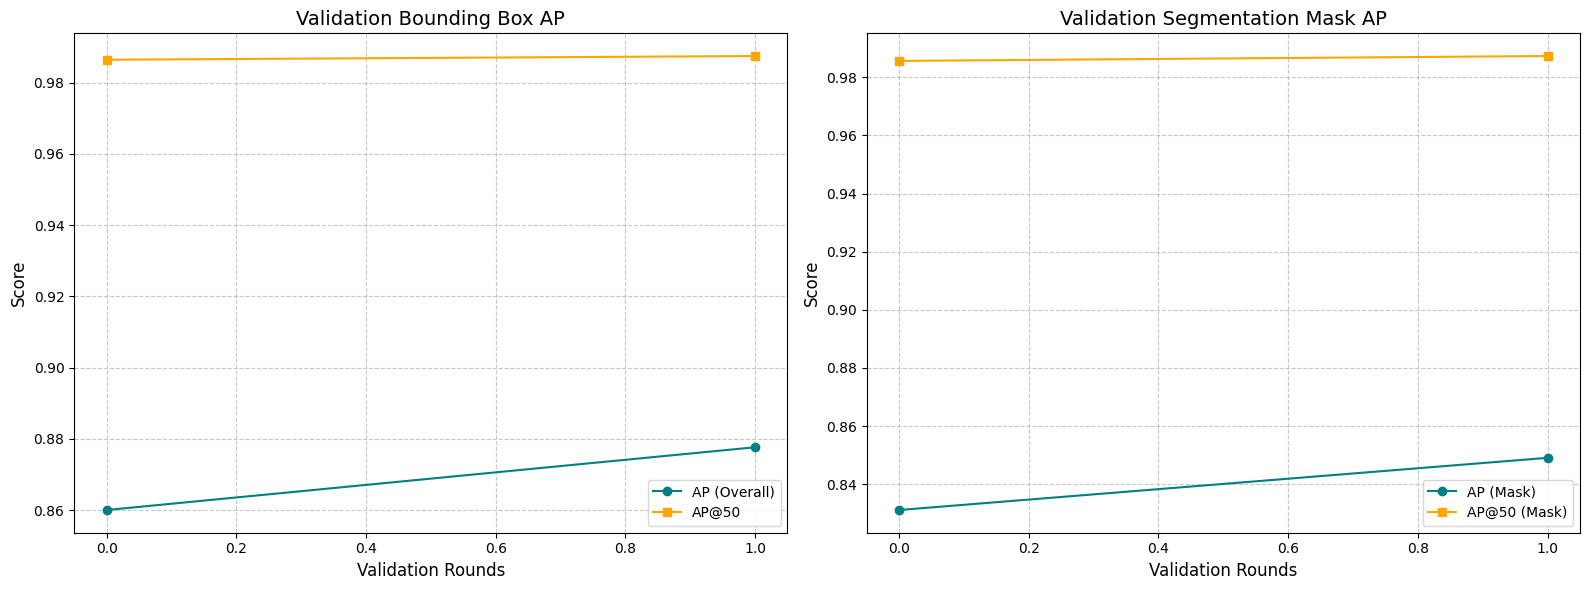

In [12]:
if not df_val.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bounding Box Average Precision
    bbox_ap = 'Meters_train/val_isic_10k_eval/detection/coco_eval_bbox_AP'
    bbox_ap50 = 'Meters_train/val_isic_10k_eval/detection/coco_eval_bbox_AP_50'
    
    if bbox_ap in df_val.columns:
        axes[0].plot(df_val.index, df_val[bbox_ap], label='AP (Overall)', marker='o', color='teal')
        axes[0].plot(df_val.index, df_val[bbox_ap50], label='AP@50', marker='s', color='orange')
    axes[0].set_title('Validation Bounding Box AP', fontsize=14)
    axes[0].set_xlabel('Validation Rounds', fontsize=12)
    axes[0].set_ylabel('Score', fontsize=12)
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    # Segmentation Mask Average Precision
    segm_ap = 'Meters_train/val_isic_10k_eval/detection/coco_eval_segm_AP'
    segm_ap50 = 'Meters_train/val_isic_10k_eval/detection/coco_eval_segm_AP_50'
    
    if segm_ap in df_val.columns:
        axes[1].plot(df_val.index, df_val[segm_ap], label='AP (Mask)', marker='o', color='teal')
        axes[1].plot(df_val.index, df_val[segm_ap50], label='AP@50 (Mask)', marker='s', color='orange')
    axes[1].set_title('Validation Segmentation Mask AP', fontsize=14)
    axes[1].set_xlabel('Validation Rounds', fontsize=12)
    axes[1].set_ylabel('Score', fontsize=12)
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

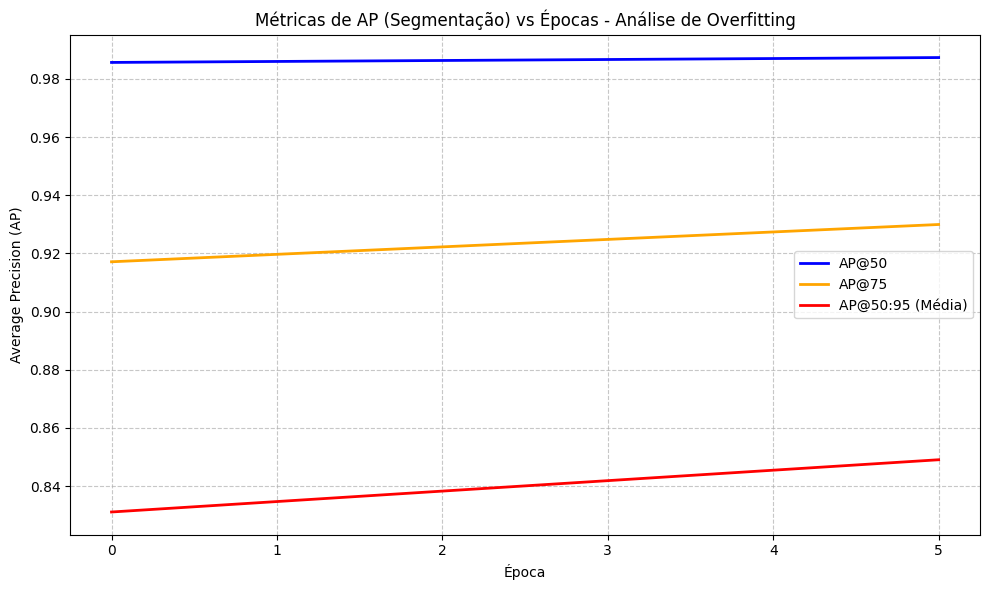

In [13]:
# Gráfico das métricas AP (Average Precision) na validação
plt.figure(figsize=(10, 6))

# Definindo as colunas de acordo com o arquivo val_stats.json
epoch_col = 'Trainer/epoch'
ap_50_col = 'Meters_train/val_isic_10k_eval/detection/coco_eval_segm_AP_50'
ap_75_col = 'Meters_train/val_isic_10k_eval/detection/coco_eval_segm_AP_75'
ap_col    = 'Meters_train/val_isic_10k_eval/detection/coco_eval_segm_AP' # Média de AP@50 até AP@95

# Plotando as linhas se os dados estiverem disponíveis
if epoch_col in df_val.columns:
    if ap_50_col in df_val.columns:
        plt.plot(df_val[epoch_col], df_val[ap_50_col], label='AP@50', color='blue', linewidth=2)
    if ap_75_col in df_val.columns:
        plt.plot(df_val[epoch_col], df_val[ap_75_col], label='AP@75', color='orange', linewidth=2)
    if ap_col in df_val.columns:
        plt.plot(df_val[epoch_col], df_val[ap_col], label='AP@50:95 (Média)', color='red', linewidth=2)

    plt.title('Métricas de AP (Segmentação) vs Épocas - Análise de Overfitting')
    plt.xlabel('Época')
    plt.ylabel('Average Precision (AP)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Coluna de épocas não encontrada. Verifique o dataframe df_val.")

## 6. Qualitative Results

In [14]:
## 6. Qualitative Results (Model vs Ground Truth)
# ================= NOVA CONFIGURAÇÃO =================
OVERLAY_MASKS = True  # Mude para False para ver as imagens lado a lado novamente
# =====================================================

def load_json_data(pred_path: Path, gt_path: Path) -> Tuple[Dict[int, List[Dict]], Dict[int, List[Dict]], Dict[int, str]]:
    preds_map, gt_map, id_to_filename = {}, {}, {}
    
    if pred_path.exists():
        with open(pred_path, 'r') as f:
            preds = json.load(f)
        for p in preds:
            preds_map.setdefault(p['image_id'], []).append(p)

    if gt_path.exists():
        with open(gt_path, 'r') as f:
            gt = json.load(f)
        for img in gt['images']:
            id_to_filename[img['id']] = img['file_name']
        for ann in gt.get('annotations', []):
            gt_map.setdefault(ann['image_id'], []).append(ann)
            
    return preds_map, gt_map, id_to_filename

def apply_mask(image: np.ndarray, mask: np.ndarray, color: List[int], alpha: float):
    for c in range(3):
        image[:, :, c] = np.where(mask == 1,
                                  image[:, :, c] * (1 - alpha) + alpha * color[c],
                                  image[:, :, c])
    return image

def draw_visualizations(img: np.ndarray, annotations: List[Dict], threshold: float = 0.0, is_gt: bool = False, color_override: List[int] = None) -> Tuple[int, np.ndarray]:
    count = 0
    img_h, img_w = img.shape[:2]
    
    # Ordena apenas predições por score (GT não possui score)
    if not is_gt:
        annotations.sort(key=lambda x: x.get('score', 0)) 

    for ann in annotations:
        score = ann.get('score', 1.0)
        if not is_gt and score < threshold: 
            continue

        # Lógica de Cores: Verde para GT, Aleatório para predição (ou cor fixa se sobreposto)
        if color_override:
            color = color_override
        else:
            color = [0, 255, 0] if is_gt else [random.randint(50, 255) for _ in range(3)]
        
        # Máscara
        if 'segmentation' in ann:
            try:
                segm = ann['segmentation']
                binary_mask = np.zeros((img_h, img_w), dtype=np.uint8)
                
                # Formato Polígono (Ground Truth Padrão COCO)
                if isinstance(segm, list):
                    for poly in segm:
                        pts = np.array(poly).reshape(-1, 2).astype(np.int32)
                        cv2.fillPoly(binary_mask, [pts], 1)
                
                # Formato RLE (Predições do Modelo)
                elif isinstance(segm, dict):
                    binary_mask = mask_utils.decode(segm)
                    if binary_mask.shape[:2] != (img_h, img_w):
                        binary_mask = cv2.resize(binary_mask, (img_w, img_h), interpolation=cv2.INTER_NEAREST)

                img = apply_mask(img, binary_mask, color, CONFIG["mask_alpha"])
                contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                cv2.drawContours(img, contours, -1, (255, 255, 255), 1)
            except Exception as e:
                pass

        # Bounding Box
        if 'bbox' in ann:
            bbox = ann['bbox']
            if all(v <= 1.1 for v in bbox):
                x, y, w, h = int(bbox[0]*img_w), int(bbox[1]*img_h), int(bbox[2]*img_w), int(bbox[3]*img_h)
            else:
                x, y, w, h = map(int, bbox)
                
            cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
            
            # Text Label
            if not is_gt:
                label = f"Pred: {score:.2f}"
                (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                cv2.rectangle(img, (x, y - 20), (x + tw, y), color, -1)
                cv2.putText(img, label, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
            else:
                label = "GT"
                (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                # Para GT, coloca a label um pouco mais para a direita se sobreposto para não conflitar com a predição
                offset_x = x + 80 if OVERLAY_MASKS else x
                cv2.rectangle(img, (offset_x, y - 20), (offset_x + tw, y), color, -1)
                cv2.putText(img, label, (offset_x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
                
        count += 1
        
    return count, img

NUM_IMAGES_TO_SHOW = 10
preds_map, gt_map, id_to_filename = load_json_data(CONFIG["pred_json"], CONFIG["gt_json"])
shown = 0

for img_id, predictions in preds_map.items():
    if shown >= NUM_IMAGES_TO_SHOW:
        break
        
    if id_to_filename and img_id in id_to_filename:
        img_path = CONFIG["images_dir"] / id_to_filename[img_id]
        if not img_path.exists():
            continue
            
        original_img = cv2.imread(str(img_path))
        if original_img is None:
            continue
            
        gt_annotations = gt_map.get(img_id, [])
        
        if OVERLAY_MASKS:
            # Imprime tudo na mesma imagem
            combined_img = original_img.copy()
            
            # 1. Ground Truth (Verde)
            gt_count, combined_img = draw_visualizations(combined_img, gt_annotations, is_gt=True, color_override=[113, 204, 46])
            
            # 2. Previsões (Vermelho)
            pred_count, combined_img = draw_visualizations(combined_img, predictions, CONFIG["score_threshold"], is_gt=False, color_override=[60, 20, 220]) # OpenCV usa BGR, então [0,0,255] é Vermelho
            
            if pred_count > 0 or gt_count > 0:
                combined_img_rgb = cv2.cvtColor(combined_img, cv2.COLOR_BGR2RGB)
                
                plt.figure(figsize=(10, 10))
                plt.imshow(combined_img_rgb)
                plt.title(f"Image: {id_to_filename[img_id]}\nGT (Verde) | Prediction (Vermelho)", fontsize=14)
                plt.axis('off')
                plt.tight_layout()
                plt.show()
                shown += 1
                
        else:
            # Imprime lado a lado
            pred_count, img_pred = draw_visualizations(original_img.copy(), predictions, CONFIG["score_threshold"], is_gt=False)
            gt_count, img_gt = draw_visualizations(original_img.copy(), gt_annotations, is_gt=True)
            
            if pred_count > 0 or gt_count > 0:
                img_pred_rgb = cv2.cvtColor(img_pred, cv2.COLOR_BGR2RGB)
                img_gt_rgb = cv2.cvtColor(img_gt, cv2.COLOR_BGR2RGB)
                
                fig, axes = plt.subplots(1, 2, figsize=(16, 8))
                
                axes[0].imshow(img_pred_rgb)
                axes[0].set_title(f"Model Predictions (Threshold: {CONFIG['score_threshold']})", fontsize=14)
                axes[0].axis('off')
                
                axes[1].imshow(img_gt_rgb)
                axes[1].set_title(f"Ground Truth (Dermatologist)", fontsize=14)
                axes[1].axis('off')
                
                fig.suptitle(f"Image: {id_to_filename[img_id]}", fontsize=16)
                plt.tight_layout()
                plt.show()
                shown += 1

## 7. Apresentação das Métricas Obtidas
print("="*50)
print("🎯 RESULTADOS DE VALIDAÇÃO (ÚLTIMA ÉPOCA) 🎯")
print("="*50)

if not df_val.empty:
    last_epoch_data = df_val.iloc[-1]
    epoch_num = last_epoch_data.get('Trainer/epoch', 'N/A')
    
    print(f"Época Analisada: {epoch_num}\n")
    
    metrics_to_print = {}
    for col, value in last_epoch_data.items():
        if "coco_eval" in col and pd.notna(value) and value != -1.0:
            clean_name = col.split('/')[-1].replace('coco_eval_', '')
            metrics_to_print[clean_name] = value

    for name, value in sorted(metrics_to_print.items()):
        if 'segm' in name:
            print(f"  🟦 Mask {name.replace('segm_', '')}: \t{value:.4f}")
        elif 'bbox' in name:
            print(f"  🟩 BBox {name.replace('bbox_', '')}: \t{value:.4f}")
else:
    print("Nenhuma métrica de validação encontrada.")
print("="*50)

🎯 RESULTADOS DE VALIDAÇÃO (ÚLTIMA ÉPOCA) 🎯
Época Analisada: 5.0

  🟩 BBox AP: 	0.8776
  🟩 BBox AP_50: 	0.9875
  🟩 BBox AP_75: 	0.9419
  🟩 BBox AP_large: 	0.8776
  🟩 BBox AP_medium: 	0.9000
  🟩 BBox AR_large: 	0.8981
  🟩 BBox AR_maxDets@1: 	0.8818
  🟩 BBox AR_maxDets@10: 	0.8981
  🟩 BBox AR_maxDets@100: 	0.8981
  🟩 BBox AR_medium: 	0.9000
  🟦 Mask AP: 	0.8491
  🟦 Mask AP_50: 	0.9873
  🟦 Mask AP_75: 	0.9299
  🟦 Mask AP_large: 	0.8490
  🟦 Mask AP_medium: 	0.9000
  🟦 Mask AR_large: 	0.8709
  🟦 Mask AR_maxDets@1: 	0.8566
  🟦 Mask AR_maxDets@10: 	0.8709
  🟦 Mask AR_maxDets@100: 	0.8709
  🟦 Mask AR_medium: 	0.9000
